In [577]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_wine
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset,DataLoader
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

torch.manual_seed(23)
np.random.seed(23)

In [578]:
dataset = load_wine()

#type(dataset.data)
#dataset.data.shape

df = pd.DataFrame(data=dataset.data,columns=dataset.feature_names)

df['target'] = dataset.target

x_datos = df.drop(columns=['target'])
y_datos = df['target']

In [579]:
print(x_datos.shape)
print(y_datos.shape)

(178, 13)
(178,)


In [580]:
y_datos.value_counts()

target
1    71
0    59
2    48
Name: count, dtype: int64

In [581]:
x_train,x_test,y_train,y_test = train_test_split(
    x_datos,y_datos,train_size=0.8,test_size=0.2,shuffle=True)

In [582]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [583]:
print(type(x_train))
print(type(y_train))

<class 'numpy.ndarray'>
<class 'pandas.core.series.Series'>


In [584]:
t_x_train = torch.from_numpy(x_train).float().to('cpu')
t_x_test = torch.from_numpy(x_test).float().to('cpu')

t_y_train = torch.from_numpy(y_train.values).long().to('cpu')
t_y_test = torch.from_numpy(y_test.values).long().to('cpu')

print(f"x train: {t_x_train.shape}, x test: {t_x_test.shape} \t y train: {t_y_train.shape}, y test: {t_y_test.shape}")

x train: torch.Size([142, 13]), x test: torch.Size([36, 13]) 	 y train: torch.Size([142]), y test: torch.Size([36])


In [585]:
train_dataset = TensorDataset(t_x_train,t_y_train)
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)

test_dataset = TensorDataset(t_x_test,t_y_test)

# RED NEURONAL

In [586]:
n_entradas = t_x_train.shape[1]

In [587]:
n_salidas = len(y_datos.value_counts())

In [588]:
class Red(nn.Module):
    def __init__(self,n_entradas,n_salidas):
        super().__init__()

        self.capa1 = nn.Linear(n_entradas,8)
        self.capa2 = nn.Linear(8,n_salidas)

    def forward(self,inputs):

        pred1 = torch.relu(self.capa1(inputs))
        pred_final = self.capa2(pred1)

        return pred_final

In [589]:
epochs = 100
lr = 0.001
estatus_print = 10

In [590]:
model = Red(n_entradas= n_entradas, n_salidas= n_salidas)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr= lr)


In [591]:
historico = []

for epoch in range(1,epochs+1):

    model.train()
    loss_acumulator = 0

    for x_batch, y_batch in train_loader:
        
        optimizer.zero_grad()
    
        y_pred = model(x_batch)
        loss = criterion(y_pred,y_batch)
        loss.backward()
        optimizer.step()

        loss_acumulator += loss
    
    loss_epoch = loss_acumulator / len(train_loader)


    model.eval()
    with torch.no_grad():

        # TRAIN EVALUATION
        y_pred_train = model(t_x_train)
        y_class_train = torch.argmax(y_pred_train,dim=1)
        accuracy_train = ((y_class_train == t_y_train).float().mean()*100).round()

        # TEST EVALUATION
        y_pred_test = model(t_x_test)
        y_class_test = torch.argmax(y_pred_test,dim=1)
        accuracy_test = ((y_class_test == t_y_test).float().mean()*100).round()


    if epoch % estatus_print == 0:
        print(f"Epoch: {epoch} \t Loss: {loss_epoch.item():.6f}")
        print(f"Accuracy TEST: {accuracy_test} \t Accuracy TRAIN: {accuracy_train}")

        historico.append({
            'Epoch':epoch,
            'Loss':round(loss_epoch.item(),4),
            'Accuracy_train': accuracy_train.item(),
            'Accuracy_test' : accuracy_test.item(),
        })

historico = pd.DataFrame(historico)


Epoch: 10 	 Loss: 0.834225
Accuracy TEST: 94.0 	 Accuracy TRAIN: 87.0
Epoch: 20 	 Loss: 0.622681
Accuracy TEST: 94.0 	 Accuracy TRAIN: 91.0
Epoch: 30 	 Loss: 0.462316
Accuracy TEST: 100.0 	 Accuracy TRAIN: 94.0
Epoch: 40 	 Loss: 0.309064
Accuracy TEST: 100.0 	 Accuracy TRAIN: 97.0
Epoch: 50 	 Loss: 0.241381
Accuracy TEST: 100.0 	 Accuracy TRAIN: 97.0
Epoch: 60 	 Loss: 0.182667
Accuracy TEST: 100.0 	 Accuracy TRAIN: 98.0
Epoch: 70 	 Loss: 0.142991
Accuracy TEST: 100.0 	 Accuracy TRAIN: 99.0
Epoch: 80 	 Loss: 0.122299
Accuracy TEST: 100.0 	 Accuracy TRAIN: 99.0
Epoch: 90 	 Loss: 0.107084
Accuracy TEST: 100.0 	 Accuracy TRAIN: 99.0
Epoch: 100 	 Loss: 0.079364
Accuracy TEST: 100.0 	 Accuracy TRAIN: 99.0


In [592]:
historico.head()

,Epoch,Loss,Accuracy_train,Accuracy_test
0,10,0.8342,87.0,94.0
1,20,0.6227,91.0,94.0
2,30,0.4623,94.0,100.0
3,40,0.3091,97.0,100.0
4,50,0.2414,97.0,100.0


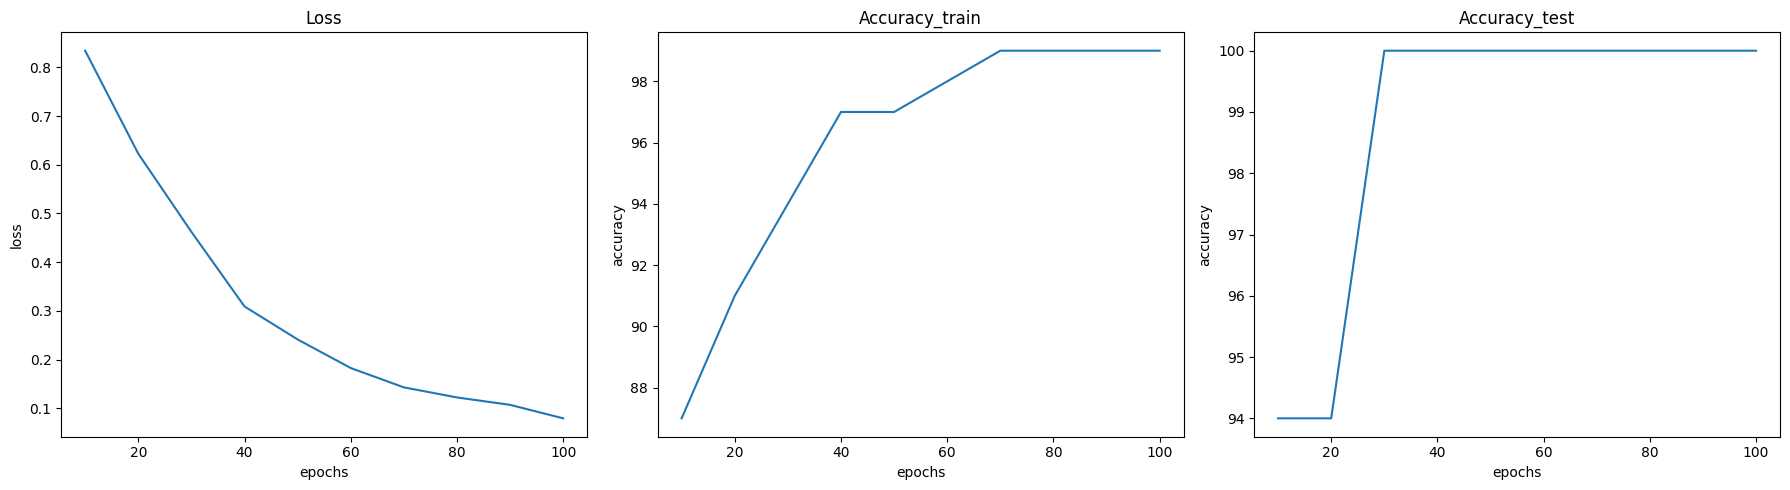

In [593]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

axes[0].plot(historico["Epoch"],historico["Loss"])
axes[0].set_title("Loss")
axes[0].set_xlabel("epochs")
axes[0].set_ylabel("loss")

axes[1].plot(historico["Epoch"],historico["Accuracy_train"])
axes[1].set_title("Accuracy_train")
axes[1].set_xlabel("epochs")
axes[1].set_ylabel("accuracy")

axes[2].plot(historico["Epoch"],historico["Accuracy_test"])
axes[2].set_title("Accuracy_test")
axes[2].set_xlabel("epochs")
axes[2].set_ylabel("accuracy")

plt.tight_layout()
plt.show()

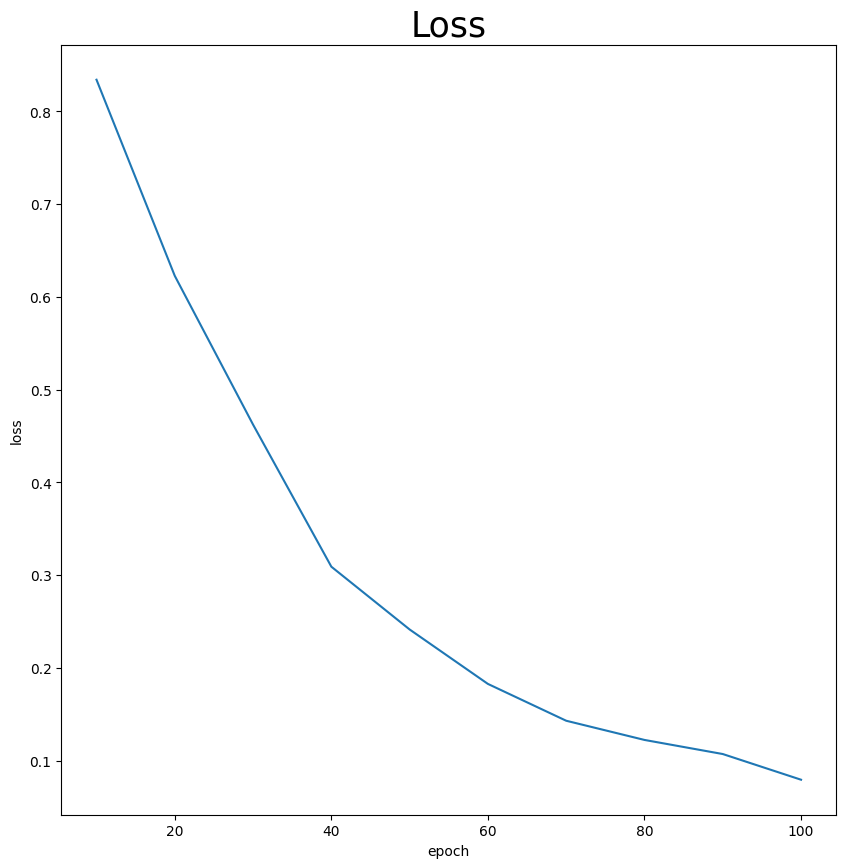

In [594]:
plt.figure(figsize=(10,10))
plt.plot(historico['Epoch'],historico['Loss'])
plt.title('Loss',fontsize=25)
plt.xlabel(xlabel='epoch')
plt.ylabel(ylabel='loss')
plt.show()

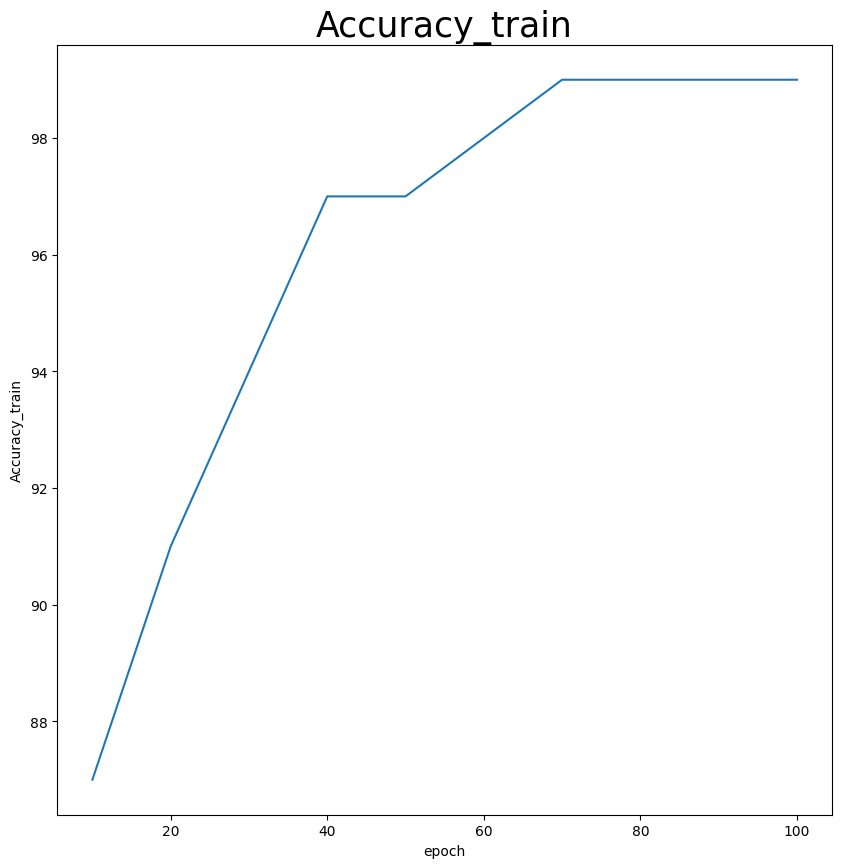

In [595]:
plt.figure(figsize=(10,10))
plt.plot(historico['Epoch'],historico['Accuracy_train'])
plt.title('Accuracy_train',fontsize=25)
plt.xlabel(xlabel='epoch')
plt.ylabel(ylabel='Accuracy_train')
plt.show()

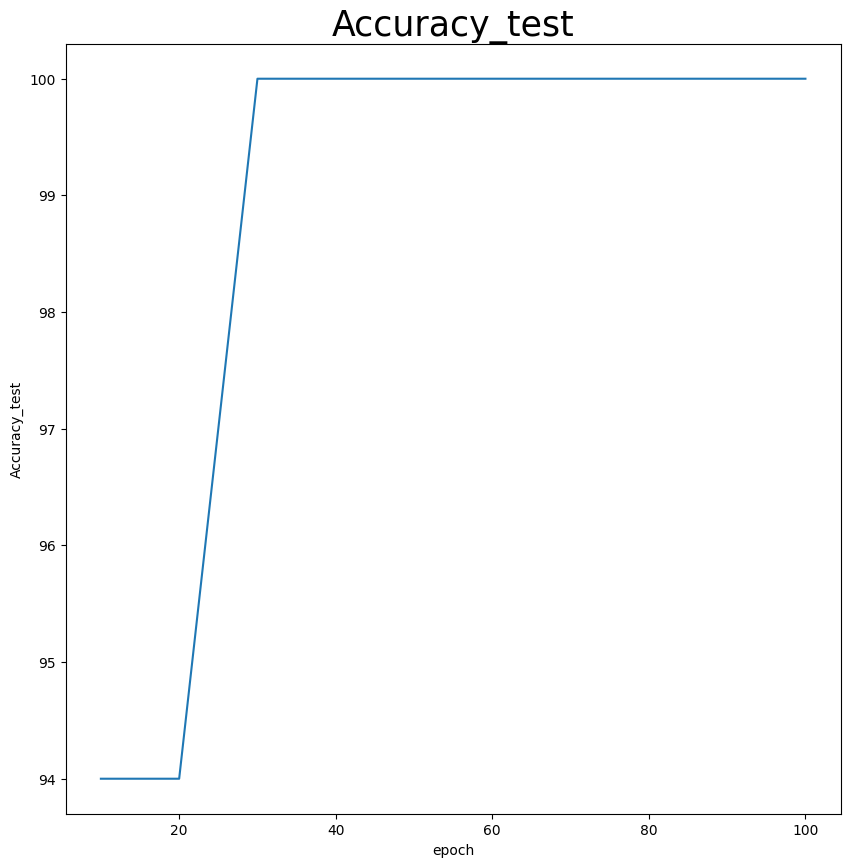

In [596]:
plt.figure(figsize=(10,10))
plt.plot(historico['Epoch'],historico['Accuracy_test'])
plt.title('Accuracy_test',fontsize=25)
plt.xlabel(xlabel='epoch')
plt.ylabel(ylabel='Accuracy_test')
plt.show()